# C.O.M.B.U.S.T.I.O.N.: (C)lassification of (O)utliers and (M)odeling (B)urn-risk (U)sing (S)tochastic (T)ree (I)ncident (O)utput (N)etworks pipeline

This notebook reproduces the Random Forest models from Section 3.1 of the paper. Four sensor configurations are evaluated, each in two variable setups with two variations:

| Config | Sensor | Precipitation | Reduced variables |
|---|---|---|---|
| FIRMS | MODIS FIRMS | No | Yes |
| FIRMS | MODIS FIRMS | No | No |
| FIRMS-CHIRPS | MODIS FIRMS | Yes (CHIRPS) | Yes |
| FIRMS-CHIRPS | MODIS FIRMS | Yes (CHIRPS) | No |
| VIIRS | VIIRS S-NPP | No | Yes |
| VIIRS | VIIRS S-NPP | No | No |
| VIIRS-CHIRPS | VIIRS S-NPP | Yes (CHIRPS) | Yes |
| VIIRS-CHIRPS | VIIRS S-NPP | Yes (CHIRPS) | No |

**Full variables** keeps `land_cover_class` and `elevation` as features. **Reduced variables** drops them, keeping only the spectral/radiometric predictors.

Data quality follows **Strategy B**: QC flags mask bad pixels as NaN (rows are preserved), and any column with more than 50% NaN in the balanced training set is dropped before fitting.

---
## 0. Setup

In [ ]:
import os
import warnings
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, precision_recall_curve, auc
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'Arial', 'font.size': 12,
                     'axes.labelweight': 'bold', 'axes.titleweight': 'bold'})

# Point this to the root of the project
working_dir = your_working_directory_here  # <-- Set this to your working directory
print(f'Working directory: {working_dir}')

Working directory: \


---
## 1. Shared Utilities

In [ ]:
QC_PATTERNS = [
    'MOD13Q1_SummaryQA_0_1-', 'MCD15A3H_FparLai_QC_bit0-',
    'MCD15A3H_FparLai_QC_3_4-', 'MOD21A1D_QC_0_1-',
    'MOD21A1D_QC_4_5-', 'MCD18A1_DSR_Quality_0_1-',
]
PERIODS = ['0B', '1B', '2B', '3B', '4B', '5B']
NAN_COL_THRESHOLD = 0.50
RF_PARAMS = dict(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
REDUX_COLS = ['land_cover_class', 'elevation']  # dropped in reduced-variable runs


def load_or_concat(raw_dir, processed_file):
    if os.path.exists(processed_file):
        return pd.read_csv(processed_file)
    dfs = [pd.read_csv(os.path.join(raw_dir, f))
           for f in os.listdir(raw_dir) if f.endswith('.csv')]
    df = pd.concat(dfs, ignore_index=True)
    os.makedirs(os.path.dirname(processed_file), exist_ok=True)
    df.to_csv(processed_file, index=False)
    return df


def filter_ndvi(df):
    ndvi_cols = [c for c in df.columns if c.startswith('NDVI_')]
    if not ndvi_cols:
        return df
    mask = pd.Series(False, index=df.index)
    for col in ndvi_cols:
        mask |= (df[col] <= 0) & df[col].notna()
    n_before = len(df)
    df = df[~mask].copy()
    print(f'  NDVI filter: removed {n_before - len(df):,} rows -> {len(df):,} remain')
    return df


def apply_qc_masking(df):
    for p in PERIODS:
        # NDVI/EVI
        qa = f'MOD13Q1_SummaryQA_0_1-{p}'
        if qa in df.columns:
            bad = df[qa] != 0
            for v in ['NDVI', 'EVI']:
                if f'{v}_{p}' in df.columns:
                    df.loc[bad, f'{v}_{p}'] = np.nan
        # LAI/FPAR
        qa0 = f'MCD15A3H_FparLai_QC_bit0-{p}'
        qa1 = f'MCD15A3H_FparLai_QC_3_4-{p}'
        if qa0 in df.columns and qa1 in df.columns:
            bad = (df[qa0] != 0) | (df[qa1] != 0)
            for v in ['LAI', 'FPAR']:
                if f'{v}_{p}' in df.columns:
                    df.loc[bad, f'{v}_{p}'] = np.nan
        # LST bitmasks
        qa4 = f'MOD21A1D_QC_0_1-{p}'
        qa5 = f'MOD21A1D_QC_4_5-{p}'
        if qa4 in df.columns and qa5 in df.columns:
            bad = (~df[qa4].isin([0])) | (~df[qa5].isin([0]))  # 0123 includes all
            if f'LST_{p}' in df.columns:
                df.loc[bad, f'LST_{p}'] = np.nan
        # SW radiation
        qa_sw = f'MCD18A1_DSR_Quality_0_1-{p}'
        if qa_sw in df.columns and f'SW_radiation_{p}' in df.columns:
            df.loc[df[qa_sw] != 1, f'SW_radiation_{p}'] = np.nan
    to_drop = [c for c in df.columns if any(c.startswith(p) for p in QC_PATTERNS)]
    df = df.drop(columns=to_drop)
    print(f'  QC masking done. Dropped {len(to_drop)} QC columns.')
    return df


def get_meta_cols(df):
    always = {'is_fire', 'confidence'}
    patterns = [
        lambda c: c in {'lat', 'lon', 'latitude', 'longitude'},
        lambda c: c == 'date' or c.startswith('date_'),
        lambda c: 'bright_ti' in c.lower(),
        lambda c: c.startswith('line_number'),
    ]
    return [c for c in df.columns if c in always or any(p(c) for p in patterns)]


def _shared_fit(df, fire, sensor_label, threshold_name, reduced, viirs_nonfire_nan):
    """
    Core training logic shared by train_firms_model and train_viirs_model.

    viirs_nonfire_nan=True  → non-fire rows have legitimately NaN features (VIIRS empty
                               cells); preserve them and fill NaNs with column medians.
    viirs_nonfire_nan=False → standard dropna on all rows (FIRMS continuous confidence).
    """
    nonfire_pool = df[df['is_fire'] == 0]
    raw_unbalance = (len(nonfire_pool) / len(fire)) if len(fire) > 0 else np.nan

    n = min(len(fire), len(nonfire_pool))
    if n == 0:
        print(f'  Skipping {threshold_name}: no samples.')
        return None
    balanced = pd.concat([fire, nonfire_pool.sample(n=n, random_state=42)], ignore_index=True)

    if reduced:
        balanced = balanced.drop(columns=[c for c in REDUX_COLS if c in balanced.columns])

    meta = get_meta_cols(balanced)
    feature_cols = [c for c in balanced.columns if c not in meta]

    nan_rates = balanced[feature_cols].isnull().mean()
    high_nan = nan_rates[nan_rates > NAN_COL_THRESHOLD].index.tolist()
    if high_nan:
        print(f'    Dropped columns (>50% NaN): {high_nan}')
        balanced = balanced.drop(columns=high_nan)
        feature_cols = [c for c in balanced.columns if c not in get_meta_cols(balanced)]

    n_before = len(balanced)
    if viirs_nonfire_nan:
        # Non-fire rows are empty VIIRS cells → all spectral features are legitimately NaN.
        # Drop bad-QC fire rows only; keep every non-fire row and impute NaNs with medians.
        fire_mask = balanced['is_fire'] == 1
        fire_clean = balanced[fire_mask].dropna(subset=feature_cols)
        nonfire_rows = balanced[~fire_mask]
        balanced = pd.concat([fire_clean, nonfire_rows], ignore_index=True)
        col_medians = balanced[feature_cols].median()
        balanced[feature_cols] = balanced[feature_cols].fillna(col_medians)
    else:
        # FIRMS: standard row-wise dropna (confidence is continuous, non-fire rows
        # have proper spectral values).
        balanced = balanced.dropna(subset=feature_cols)

    variant_label = 'reduced' if reduced else 'full'
    fire_final = (balanced['is_fire'] == 1).sum()
    nonfire_final = (balanced['is_fire'] == 0).sum()
    final_balance_ratio = (nonfire_final / fire_final) if fire_final > 0 else np.nan

    print(f'  [{variant_label}] {threshold_name}: {len(balanced):,} rows '
          f'(removed {n_before - len(balanced):,}) | '
          f'fire {fire_final:,} / nonfire {nonfire_final:,}')
    print(f'    Original imbalance: {raw_unbalance:.3f} | Final balance: {final_balance_ratio:.3f}')

    X = balanced[feature_cols].drop(
        columns=[c for c in balanced[feature_cols].columns if 'bright_ti' in c.lower()],
        errors='ignore')
    y = balanced['is_fire']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_train, y_train)

    model_path = os.path.join(working_dir, 'models',
                              f'RF_{sensor_label}_{threshold_name}_{"reduced" if reduced else "full"}.joblib')
    joblib.dump(model, model_path)

    y_pred = model.predict(X_test)
    proba  = model.predict_proba(X_test)[:, 1]

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(rec, prec)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0
    far = fp / (fp + tn) if (fp + tp) > 0 else 0
    fi  = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

    print(f'    Accuracy: {test_acc:.3f} | ROC-AUC: {roc_auc:.3f} | '
          f'POD: {pod:.3f} | FAR: {far:.3f} | Overfit: {train_acc - test_acc:.3f}')

    return dict(
        model=model, X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test, y_pred=y_pred, proba=proba,
        train_acc=train_acc, test_acc=test_acc, roc_auc=roc_auc,
        pr_auc=pr_auc, pod=pod, far=far, overfit=train_acc - test_acc,
        cm=cm, fi=fi, n_samples=len(balanced),
        raw_unbalance=raw_unbalance,
        balanced_unbalance=final_balance_ratio,
        threshold_name=threshold_name, sensor=sensor_label, reduced=reduced
    )


def train_firms_model(df, conf_threshold, threshold_name, sensor_label, reduced=False):
    """
    Train one RF model for FIRMS / FIRMS-CHIRPS.
    Confidence is a continuous percentage (0-100); fires are selected with >= threshold.
    Non-fire rows may have NaN confidence but have valid spectral features.
    """
    fire = df[(df['is_fire'] == 1) & (df['confidence'] >= conf_threshold)]
    return _shared_fit(df, fire, sensor_label, threshold_name, reduced,
                       viirs_nonfire_nan=False)


def train_viirs_model(df, conf_threshold, threshold_name, sensor_label, reduced=False):
    """
    Train one RF model for VIIRS / VIIRS-CHIRPS.
    Confidence is categorical: 1=nominal, 2=high (0=empty, always excluded).
    Non-fire rows are empty cells with NaN confidence AND NaN spectral features.

    conf_threshold values:
      1        -> confidence == 1        (nominal only)
      (1, 2)   -> confidence in [1, 2]   (nominal + high, i.e. >0)
      2        -> confidence == 2        (high only)
    """
    if isinstance(conf_threshold, tuple):
        lo, hi = conf_threshold
        fire = df[(df['is_fire'] == 1) & (df['confidence'] >= lo) & (df['confidence'] <= hi)]
    else:
        fire = df[(df['is_fire'] == 1) & (df['confidence'] == conf_threshold)]
    return _shared_fit(df, fire, sensor_label, threshold_name, reduced,
                       viirs_nonfire_nan=True)


def run_firms_sensor(df, thresholds, sensor_label):
    """Run FIRMS / FIRMS-CHIRPS: continuous confidence >= threshold."""
    results = {}
    for name, thr in thresholds.items():
        for variant, redux in [('full', False), ('reduced', True)]:
            r = train_firms_model(df, thr, name, sensor_label, reduced=redux)
            if r:
                results[(name, variant)] = r
    return results


def run_viirs_sensor(df, thresholds, sensor_label):
    """Run VIIRS / VIIRS-CHIRPS: categorical confidence with exact or range matching."""
    results = {}
    for name, thr in thresholds.items():
        for variant, redux in [('full', False), ('reduced', True)]:
            r = train_viirs_model(df, thr, name, sensor_label, reduced=redux)
            if r:
                results[(name, variant)] = r
    return results


def summary_table(results, sensor_label):
    rows = []
    for (thr, variant), r in results.items():
        raw_ratio = r['raw_unbalance']
        final_ratio = r['balanced_unbalance']
        raw_fire_pct = 100 / (1 + raw_ratio) if raw_ratio > 0 else 0
        raw_nonfire_pct = 100 - raw_fire_pct
        final_fire_pct = 100 / (1 + final_ratio) if final_ratio > 0 else 0
        final_nonfire_pct = 100 - final_fire_pct
        rows.append({
            'Threshold': thr,
            'Variables': variant,
            'Samples': r['n_samples'],
            'Orig_Ratio': f"{raw_ratio:.3f}",
            'Orig_Fire%': f"{raw_fire_pct:.1f}%",
            'Orig_NonFire%': f"{raw_nonfire_pct:.1f}%",
            'Final_Ratio': f"{final_ratio:.3f}",
            'Final_Fire%': f"{final_fire_pct:.1f}%",
            'Final_NonFire%': f"{final_nonfire_pct:.1f}%",
            'Accuracy': f"{r['test_acc']:.3f}",
            'ROC-AUC': f"{r['roc_auc']:.3f}",
            'PR-AUC':  f"{r['pr_auc']:.3f}",
            'POD': f"{r['pod']:.3f}",
            'FAR': f"{r['far']:.3f}",
            'Overfit': f"{r['overfit']:.3f}",
            'Top Feature': r['fi'].index[0],
        })
    df_out = pd.DataFrame(rows)
    print(f'\n{sensor_label} Results')
    print('=' * 160)
    print(df_out.to_string(index=False))
    return df_out


def plot_results(results, sensor_label, thresholds):
    thr_names = list(thresholds.keys())
    variants = ['full', 'reduced']
    colors = {'full': '#1f77b4', 'reduced': '#ff7f0e'}
    x = np.arange(len(thr_names))
    width = 0.35

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, (metric, label) in zip(axes, [('test_acc', 'Accuracy'), ('roc_auc', 'ROC-AUC'),
                                           ('pod', 'POD'), ('far', 'FAR')]):
        for i, variant in enumerate(variants):
            vals = [results.get((t, variant), {}).get(metric, np.nan) for t in thr_names]
            bars = ax.bar(x + (i - 0.5) * width, vals, width,
                          label=variant, color=colors[variant], edgecolor='black')
            for b in bars:
                h = b.get_height()
                if not np.isnan(h):
                    ax.text(b.get_x() + b.get_width() / 2, h + 0.01,
                            f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(thr_names, rotation=15, ha='right')
        ax.set_title(label, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'{sensor_label}: Full vs Reduced Variables', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    n_thr = len(thr_names)
    fig, axes = plt.subplots(2, n_thr, figsize=(5 * n_thr, 8))
    if n_thr == 1:
        axes = axes.reshape(2, 1)
    for row, variant in enumerate(variants):
        for col, thr in enumerate(thr_names):
            ax = axes[row, col]
            r = results.get((thr, variant))
            if r:
                fpr, tpr, _ = roc_curve(r['y_test'], r['proba'])
                ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={r["roc_auc"]:.3f}')
            ax.plot([0, 1], [0, 1], '--', color='navy', lw=1.5)
            ax.set_title(f'{variant} | {thr}', fontweight='bold')
            ax.set_xlabel('FPR')
            ax.set_ylabel('TPR')
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)
    fig.suptitle(f'{sensor_label}: ROC Curves', fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    r0 = results.get((thr_names[0], 'full'))
    if r0:
        fi = r0['fi'].head(10)
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.barplot(x=fi.values, y=fi.index, palette='viridis', ax=ax)
        ax.set_title(f'{sensor_label}: Top 10 Features (full, {thr_names[0]})', fontweight='bold')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()


print('Utilities ready.')


Utilities ready.


---
## 2. FIRMS (MODIS, no precipitation)

Confidence thresholds: 80%, 90%, 95%.

In [ ]:
firms_raw  = working_dir + 'firms_raw_data_directory_here'  # <-- Set this to your FIRMS raw data directory
firms_proc = working_dir + 'firms_processed_data_file_here'  # <-- Set this to your FIRMS processed data file
df_firms = load_or_concat(firms_raw, firms_proc)
print(f'Raw shape: {df_firms.shape}')

df_firms = filter_ndvi(df_firms)
drop_meta = ['date', 'lon', 'lat', 'line_number'] #+ [c for c in df_firms.columns if c.startswith('LST_')]
df_firms = df_firms.drop(columns=[c for c in drop_meta if c in df_firms.columns])
df_firms = apply_qc_masking(df_firms)
print(f'Post-QC shape: {df_firms.shape} | Residual NaNs: {df_firms.isnull().sum().sum():,}')

Raw shape: (86090, 80)
  NDVI filter: removed 995 rows -> 85,095 remain
  QC masking done. Dropped 36 QC columns.
Post-QC shape: (85095, 40) | Residual NaNs: 862,894


In [4]:
firms_thresholds = {'80_conf': 80, '90_conf': 90, '95_conf': 95}

print('Training FIRMS models (full + reduced)...')
firms_results = run_firms_sensor(df_firms, firms_thresholds, 'FIRMS')

Training FIRMS models (full + reduced)...
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] 80_conf: 11,822 rows (removed 21,848) | fire 7,490 / nonfire 4,332
    Original imbalance: 2.498 | Final balance: 0.578
    Accuracy: 0.932 | ROC-AUC: 0.982 | POD: 0.945 | FAR: 0.090 | Overfit: 0.050
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [reduced] 80_conf: 11,822 rows (removed 21,848) | fire 7,490 / nonfire 4,332
    Original imbalance: 2.498 | Final balance: 0.578
    Accuracy: 0.848 | ROC-AUC: 0.934 | POD: 0.917 | FAR: 0.270 | Overfit: 0.122
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] 90_conf: 8,092 rows (removed 14,736) | fire 5,251 / nonfire 2,841
    Original imbalance: 3.685 | Final balance: 0.541
    Accuracy: 0.928 | ROC-AUC: 0.979 | POD: 0.943 | FAR: 0.100 | Overfit: 0.054
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B


FIRMS Results
Threshold Variables  Samples Orig_Ratio Orig_Fire% Orig_NonFire% Final_Ratio Final_Fire% Final_NonFire% Accuracy ROC-AUC PR-AUC   POD   FAR Overfit      Top Feature
  80_conf      full    11822      2.498      28.6%         71.4%       0.578       63.4%          36.6%    0.932   0.982  0.990 0.945 0.090   0.050 land_cover_class
  80_conf   reduced    11822      2.498      28.6%         71.4%       0.578       63.4%          36.6%    0.848   0.934  0.963 0.917 0.270   0.122  SW_radiation_1B
  90_conf      full     8092      3.685      21.3%         78.7%       0.541       64.9%          35.1%    0.928   0.979  0.988 0.943 0.100   0.054 land_cover_class
  90_conf   reduced     8092      3.685      21.3%         78.7%       0.541       64.9%          35.1%    0.847   0.924  0.959 0.919 0.287   0.122           LAI_0B
  95_conf      full     6480      4.652      17.7%         82.3%       0.520       65.8%          34.2%    0.931   0.979  0.989 0.951 0.106   0.048 land_cover_c

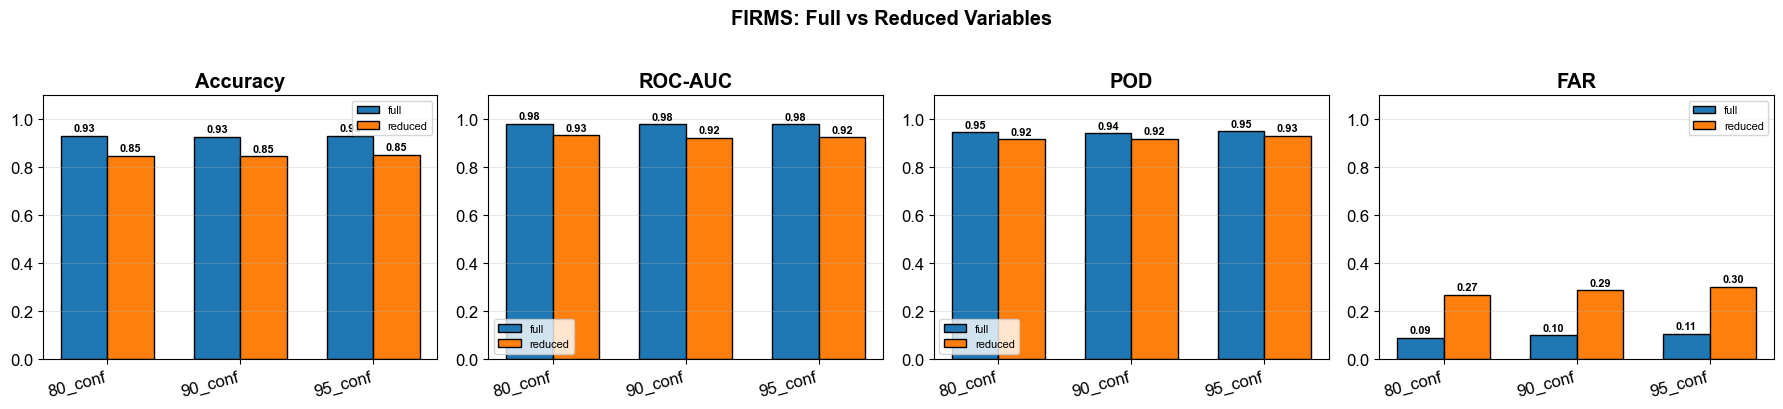

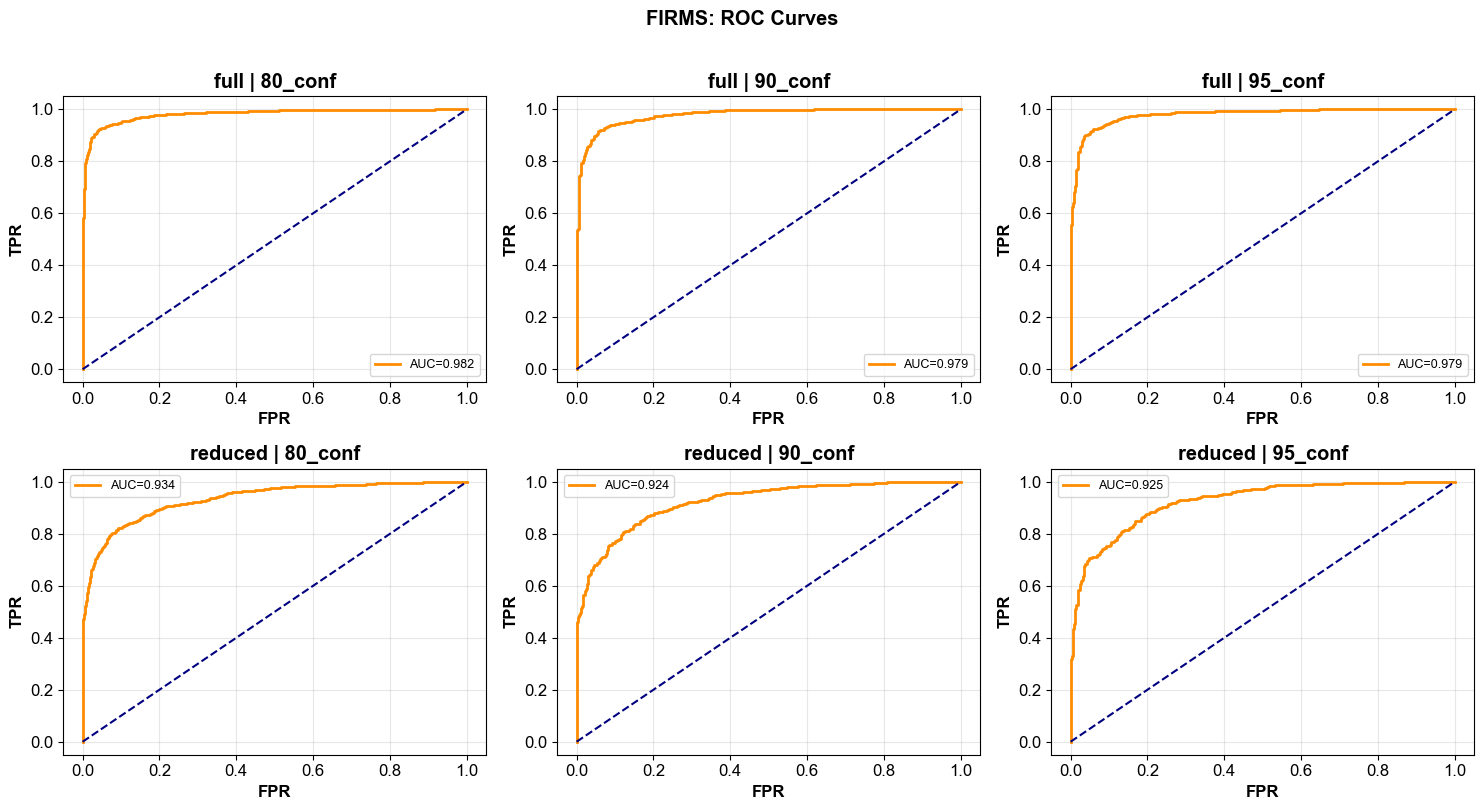

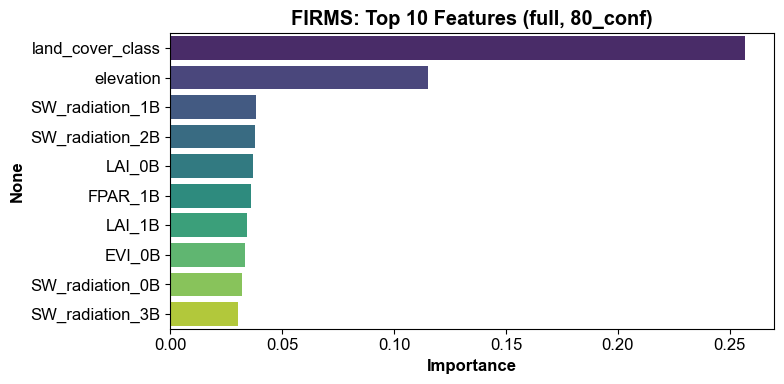

In [5]:
firms_summary = summary_table(firms_results, 'FIRMS')
plot_results(firms_results, 'FIRMS', firms_thresholds)

---
## 3. FIRMS-CHIRPS (MODIS + precipitation)

Adds CHIRPS accumulated precipitation as features.

In [ ]:
chirps_raw  = working_dir + 'firms_chirps_raw_data_directory_here'  # <-- Set this to your FIRPS-CHIRPS raw data directory
chirps_proc = working_dir + 'firms_chirps_processed_data_file_here'  # <-- Set this to your FIRPS-CHIRPS processed data file
df_chirps = load_or_concat(chirps_raw, chirps_proc)
print(f'Raw shape: {df_chirps.shape}')

df_chirps = filter_ndvi(df_chirps)
drop_meta = ['date', 'lon', 'lat', 'line_number'] #+ [c for c in df_chirps.columns if c.startswith('LST_')]
df_chirps = df_chirps.drop(columns=[c for c in drop_meta if c in df_chirps.columns])
df_chirps = apply_qc_masking(df_chirps)
print(f'Post-QC shape: {df_chirps.shape} | Residual NaNs: {df_chirps.isnull().sum().sum():,}')

Raw shape: (86090, 86)
  NDVI filter: removed 995 rows -> 85,095 remain
  QC masking done. Dropped 36 QC columns.
Post-QC shape: (85095, 46) | Residual NaNs: 862,894


In [7]:
print('Training FIRMS-CHIRPS models (full + reduced)...')
chirps_results = run_firms_sensor(df_chirps, firms_thresholds, 'FIRMS-CHIRPS')

Training FIRMS-CHIRPS models (full + reduced)...
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] 80_conf: 11,822 rows (removed 21,848) | fire 7,490 / nonfire 4,332
    Original imbalance: 2.498 | Final balance: 0.578
    Accuracy: 0.939 | ROC-AUC: 0.983 | POD: 0.947 | FAR: 0.075 | Overfit: 0.048
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [reduced] 80_conf: 11,822 rows (removed 21,848) | fire 7,490 / nonfire 4,332
    Original imbalance: 2.498 | Final balance: 0.578
    Accuracy: 0.862 | ROC-AUC: 0.938 | POD: 0.922 | FAR: 0.241 | Overfit: 0.114
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] 90_conf: 8,092 rows (removed 14,736) | fire 5,251 / nonfire 2,841
    Original imbalance: 3.685 | Final balance: 0.541
    Accuracy: 0.930 | ROC-AUC: 0.980 | POD: 0.939 | FAR: 0.088 | Overfit: 0.054
    Dropped columns (>50% NaN): ['LST_5B', 


FIRMS-CHIRPS Results
Threshold Variables  Samples Orig_Ratio Orig_Fire% Orig_NonFire% Final_Ratio Final_Fire% Final_NonFire% Accuracy ROC-AUC PR-AUC   POD   FAR Overfit      Top Feature
  80_conf      full    11822      2.498      28.6%         71.4%       0.578       63.4%          36.6%    0.939   0.983  0.991 0.947 0.075   0.048 land_cover_class
  80_conf   reduced    11822      2.498      28.6%         71.4%       0.578       63.4%          36.6%    0.862   0.938  0.964 0.922 0.241   0.114  SW_radiation_1B
  90_conf      full     8092      3.685      21.3%         78.7%       0.541       64.9%          35.1%    0.930   0.980  0.989 0.939 0.088   0.054 land_cover_class
  90_conf   reduced     8092      3.685      21.3%         78.7%       0.541       64.9%          35.1%    0.855   0.931  0.964 0.919 0.264   0.120  SW_radiation_1B
  95_conf      full     6480      4.652      17.7%         82.3%       0.520       65.8%          34.2%    0.931   0.981  0.990 0.946 0.097   0.051 land_

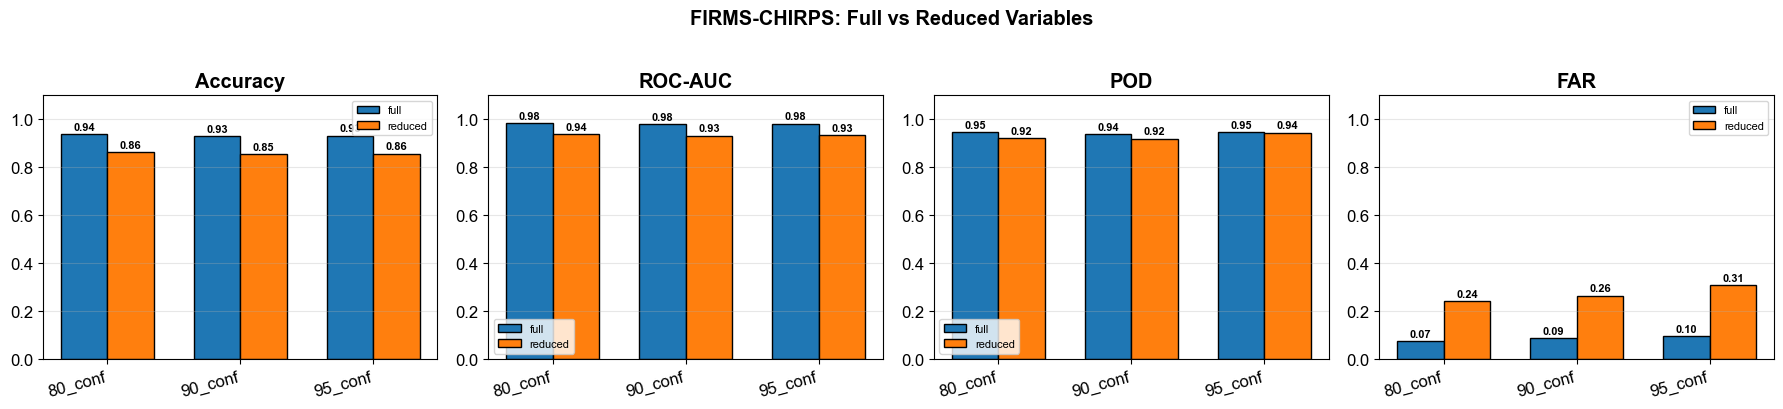

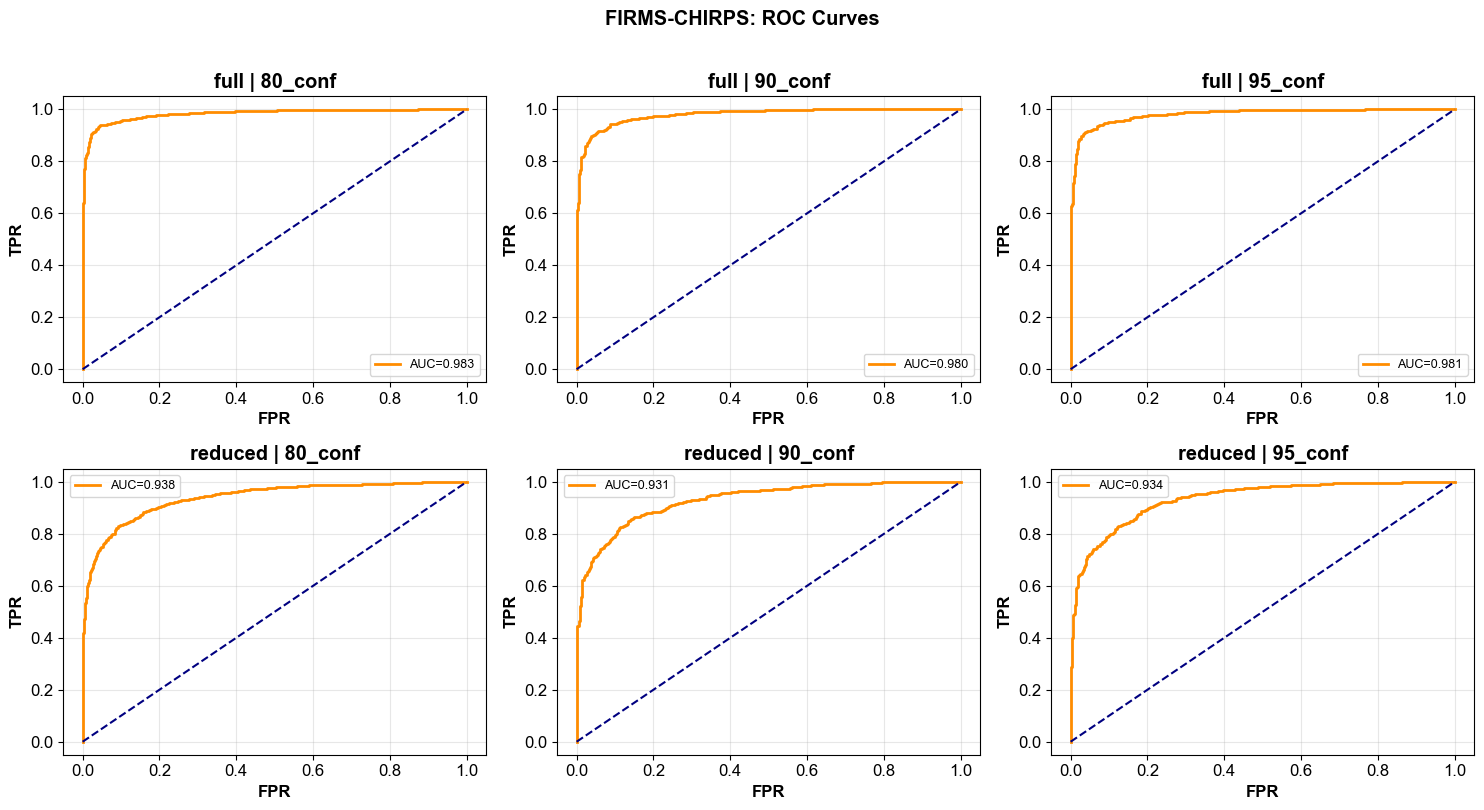

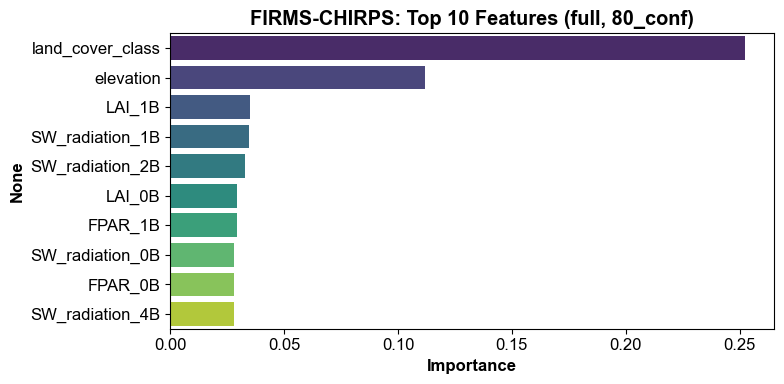

In [8]:
chirps_summary = summary_table(chirps_results, 'FIRMS-CHIRPS')
plot_results(chirps_results, 'FIRMS-CHIRPS', firms_thresholds)

---
## 4. VIIRS S-NPP (no precipitation)

VIIRS confidence is categorical: 0 = empty (excluded), 1 = nominal, 2 = high. Non-fire samples are empty cells with NaN confidence. Thresholds: =1 (nominal only), >1 i.e. =2 (high only), =2 (high only, explicit alias).

In [ ]:
viirs_raw  = working_dir + 'viirs_raw_data_directory_here'  # <-- Set this to your VIIRS raw data directory
viirs_proc = working_dir + 'viirs_processed_data_file_here'  # <-- Set this to your VIIRS processed data file
df_viirs = load_or_concat(viirs_raw, viirs_proc)
print(f'Raw shape: {df_viirs.shape}')

df_viirs = filter_ndvi(df_viirs)
drop_meta = ['date', 'lon', 'lat', 'line_number'] + \
            [c for c in df_viirs.columns if 'bright_ti' in c.lower()]
            # [c for c in df_viirs.columns if c.startswith('LST_')]
df_viirs = df_viirs.drop(columns=[c for c in drop_meta if c in df_viirs.columns])
df_viirs = apply_qc_masking(df_viirs)
print(f'Post-QC shape: {df_viirs.shape} | Residual NaNs: {df_viirs.isnull().sum().sum():,}')

Raw shape: (10124, 81)
  NDVI filter: removed 1 rows -> 10,123 remain
  QC masking done. Dropped 36 QC columns.
Post-QC shape: (10123, 40) | Residual NaNs: 99,462


In [10]:
# VIIRS confidence is categorical: 0=empty (excluded), 1=nominal, 2=high.
# nominal_conf=1 (==1), above-nominal_conf=(1,2) (>=1, nominal+high), high_conf=2 (==2)
viirs_thresholds = {'nominal_conf': 1, 'above-nominal_conf': (1, 2), 'high_conf': 2}

print('Training VIIRS models (full + reduced)...')
viirs_results = run_viirs_sensor(df_viirs, viirs_thresholds, 'VIIRS')

Training VIIRS models (full + reduced)...
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] nominal_conf: 5,492 rows (removed 3,576) | fire 958 / nonfire 4,534
    Original imbalance: 1.116 | Final balance: 4.733
    Accuracy: 0.914 | ROC-AUC: 0.982 | POD: 0.510 | FAR: 0.001 | Overfit: 0.058
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [reduced] nominal_conf: 5,492 rows (removed 3,576) | fire 958 / nonfire 4,534
    Original imbalance: 1.116 | Final balance: 4.733
    Accuracy: 0.890 | ROC-AUC: 0.965 | POD: 0.380 | FAR: 0.002 | Overfit: 0.068
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] above-nominal_conf: 6,153 rows (removed 3,937) | fire 1,108 / nonfire 5,045
    Original imbalance: 1.003 | Final balance: 4.553
    Accuracy: 0.920 | ROC-AUC: 0.975 | POD: 0.572 | FAR: 0.003 | Overfit: 0.051
    Dropped columns (>50% NaN): ['LST_


VIIRS Results
         Threshold Variables  Samples Orig_Ratio Orig_Fire% Orig_NonFire% Final_Ratio Final_Fire% Final_NonFire% Accuracy ROC-AUC PR-AUC   POD   FAR Overfit Top Feature
      nominal_conf      full     5492      1.116      47.2%         52.8%       4.733       17.4%          82.6%    0.914   0.982  0.934 0.510 0.001   0.058   elevation
      nominal_conf   reduced     5492      1.116      47.2%         52.8%       4.733       17.4%          82.6%    0.890   0.965  0.888 0.380 0.002   0.068      LAI_0B
above-nominal_conf      full     6153      1.003      49.9%         50.1%       4.553       18.0%          82.0%    0.920   0.975  0.924 0.572 0.003   0.051   elevation
above-nominal_conf   reduced     6153      1.003      49.9%         50.1%       4.553       18.0%          82.0%    0.896   0.967  0.897 0.441 0.004   0.066      LAI_0B
         high_conf      full      661      9.906       9.2%         90.8%       3.407       22.7%          77.3%    0.827   0.905  0.751 0.2

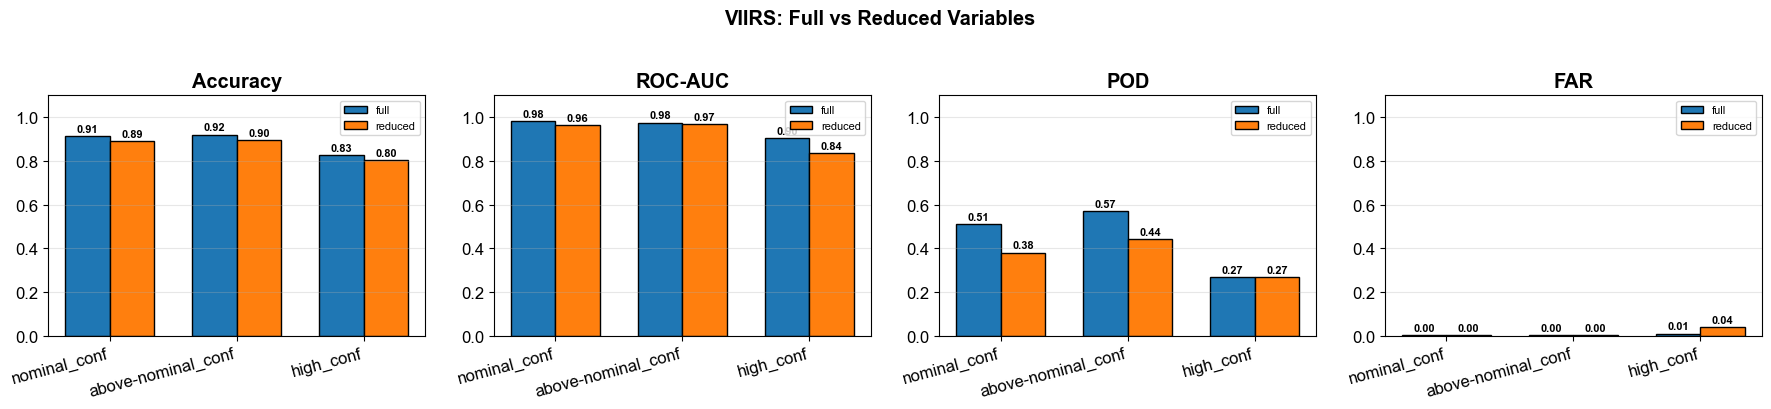

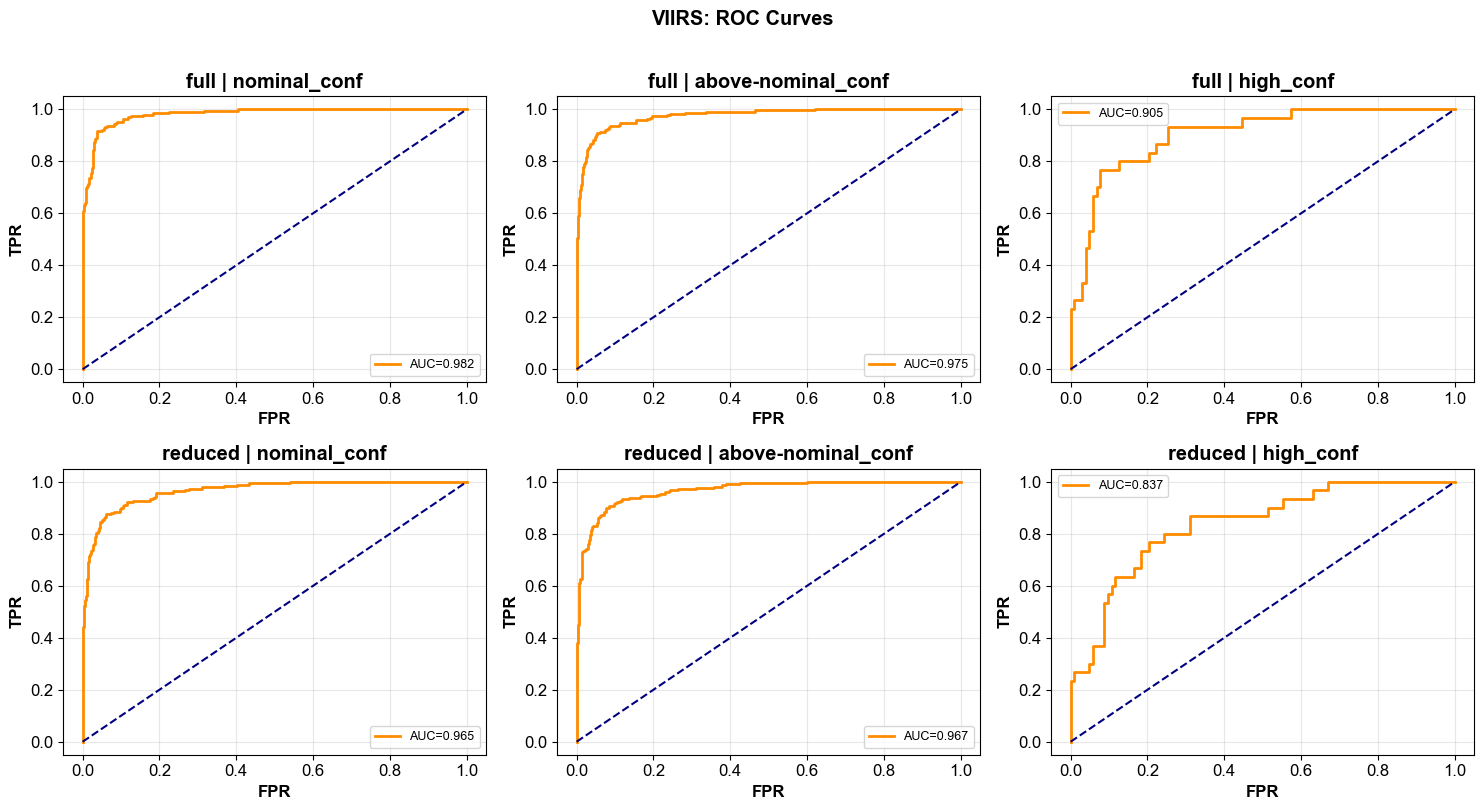

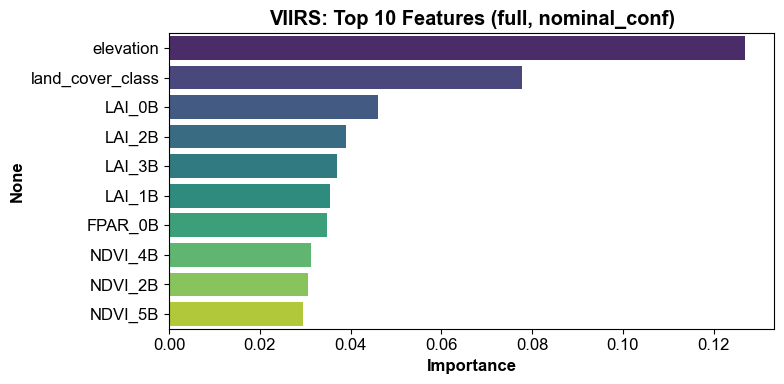

In [11]:
viirs_summary = summary_table(viirs_results, 'VIIRS')
plot_results(viirs_results, 'VIIRS', viirs_thresholds)

---
## 5. VIIRS-CHIRPS S-NPP (VIIRS + precipitation)

In [ ]:
vc_raw  = working_dir + 'viirs_chirps_raw_data_directory_here'  # <-- Set this to your VIIRS-CHIRPS raw data directory
vc_proc = working_dir + 'viirs_chirps_processed_data_file_here'  # <-- Set this to your VIIRS-CHIRPS processed data file
df_vc = load_or_concat(vc_raw, vc_proc)
print(f'Raw shape: {df_vc.shape}')

df_vc = filter_ndvi(df_vc)
drop_meta = ['date', 'lon', 'lat', 'line_number'] + \
            [c for c in df_vc.columns if 'bright_ti' in c.lower()]
            # [c for c in df_vc.columns if c.startswith('LST_')]
df_vc = df_vc.drop(columns=[c for c in drop_meta if c in df_vc.columns])
df_vc = apply_qc_masking(df_vc)
print(f'Post-QC shape: {df_vc.shape} | Residual NaNs: {df_vc.isnull().sum().sum():,}')

Raw shape: (10124, 87)
  NDVI filter: removed 1 rows -> 10,123 remain
  QC masking done. Dropped 36 QC columns.
Post-QC shape: (10123, 46) | Residual NaNs: 99,462


In [13]:
print('Training VIIRS-CHIRPS models (full + reduced)...')
vc_results = run_viirs_sensor(df_vc, viirs_thresholds, 'VIIRS-CHIRPS')

Training VIIRS-CHIRPS models (full + reduced)...
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] nominal_conf: 5,492 rows (removed 3,576) | fire 958 / nonfire 4,534
    Original imbalance: 1.116 | Final balance: 4.733
    Accuracy: 0.919 | ROC-AUC: 0.981 | POD: 0.536 | FAR: 0.000 | Overfit: 0.053
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [reduced] nominal_conf: 5,492 rows (removed 3,576) | fire 958 / nonfire 4,534
    Original imbalance: 1.116 | Final balance: 4.733
    Accuracy: 0.888 | ROC-AUC: 0.968 | POD: 0.365 | FAR: 0.001 | Overfit: 0.071
    Dropped columns (>50% NaN): ['LST_5B', 'LST_4B', 'LST_3B', 'LST_2B', 'LST_1B', 'LST_0B']
  [full] above-nominal_conf: 6,153 rows (removed 3,937) | fire 1,108 / nonfire 5,045
    Original imbalance: 1.003 | Final balance: 4.553
    Accuracy: 0.918 | ROC-AUC: 0.972 | POD: 0.559 | FAR: 0.003 | Overfit: 0.053
    Dropped columns (>50% NaN):


VIIRS-CHIRPS Results
         Threshold Variables  Samples Orig_Ratio Orig_Fire% Orig_NonFire% Final_Ratio Final_Fire% Final_NonFire% Accuracy ROC-AUC PR-AUC   POD   FAR Overfit Top Feature
      nominal_conf      full     5492      1.116      47.2%         52.8%       4.733       17.4%          82.6%    0.919   0.981  0.933 0.536 0.000   0.053   elevation
      nominal_conf   reduced     5492      1.116      47.2%         52.8%       4.733       17.4%          82.6%    0.888   0.968  0.891 0.365 0.001   0.071      LAI_0B
above-nominal_conf      full     6153      1.003      49.9%         50.1%       4.553       18.0%          82.0%    0.918   0.972  0.919 0.559 0.003   0.053   elevation
above-nominal_conf   reduced     6153      1.003      49.9%         50.1%       4.553       18.0%          82.0%    0.899   0.962  0.887 0.450 0.002   0.061      LAI_1B
         high_conf      full      661      9.906       9.2%         90.8%       3.407       22.7%          77.3%    0.820   0.898  0.

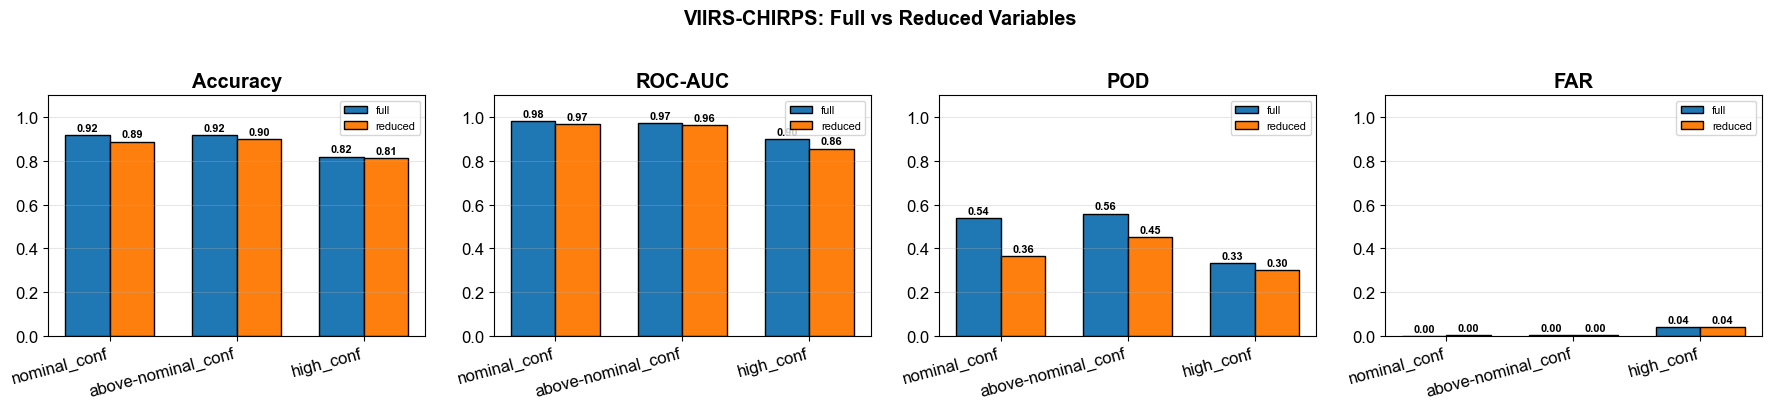

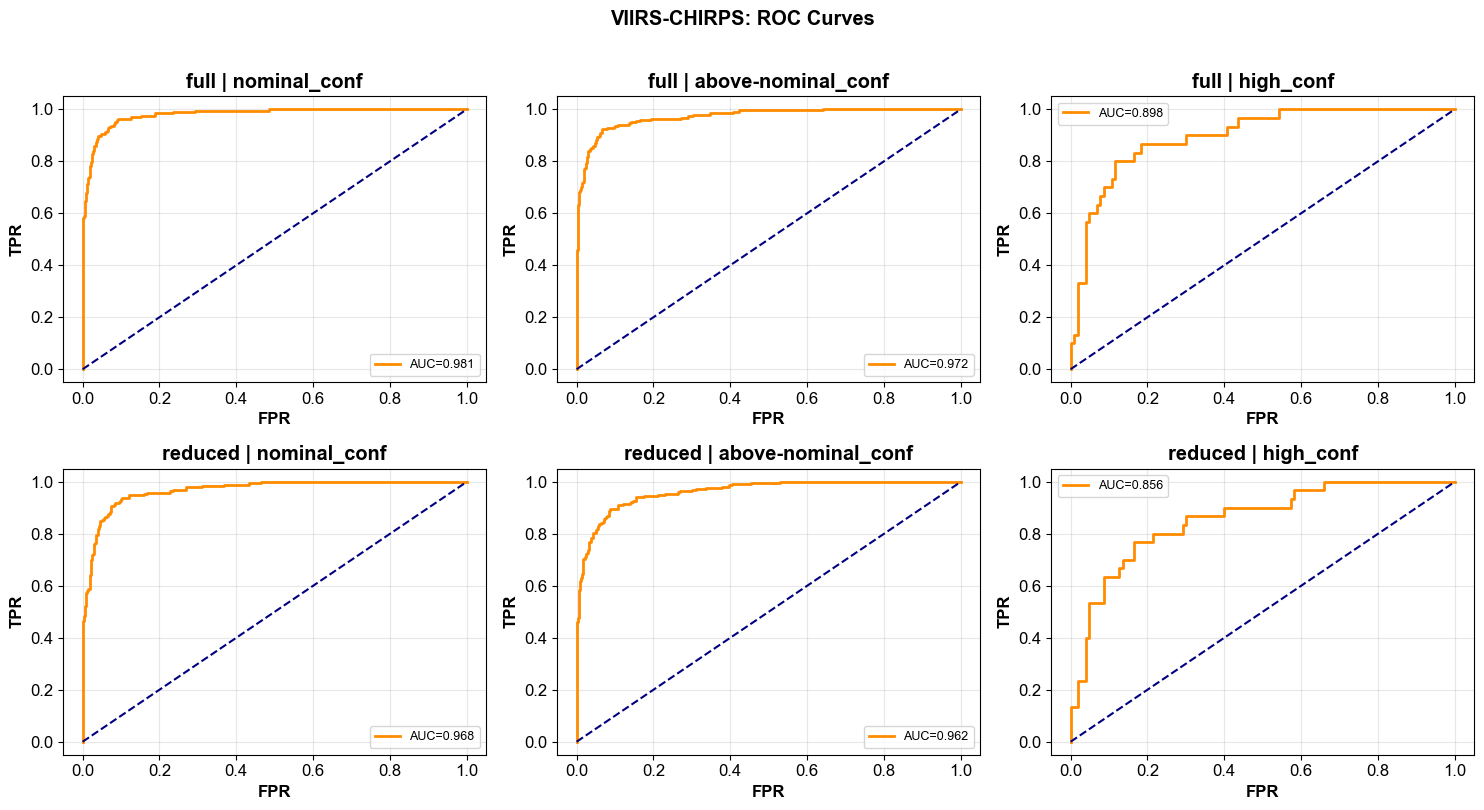

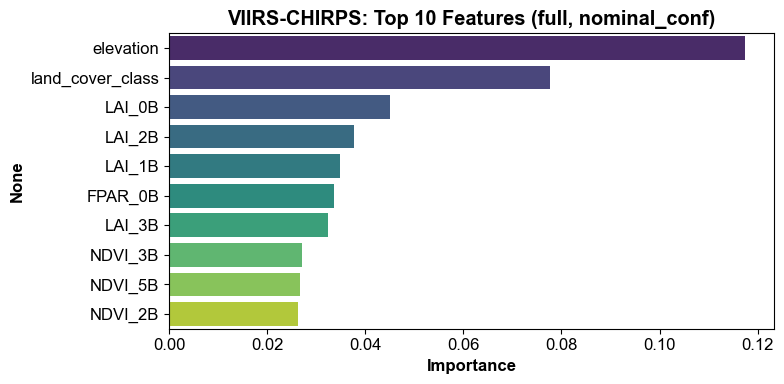

In [14]:
vc_summary = summary_table(vc_results, 'VIIRS-CHIRPS')
plot_results(vc_results, 'VIIRS-CHIRPS', viirs_thresholds)

---
## 6. Cross-sensor Comparison (Table 2)

All sensors, all thresholds, full and reduced variables.

In [ ]:
def results_to_df(results, sensor):
    rows = []
    for (thr, variant), r in results.items():
        rows.append({
            'Sensor': sensor, 'Threshold': thr, 'Variables': variant,
            'Samples': r['n_samples'],
            'Accuracy': round(r['test_acc'], 3),
            'ROC-AUC': round(r['roc_auc'], 3),
            'PR-AUC':  round(r['pr_auc'],  3),
            'POD': round(r['pod'], 3),
            'FAR': round(r['far'], 3),
            'Overfit': round(r['overfit'], 3),
        })
    return pd.DataFrame(rows)


all_results = pd.concat([
    results_to_df(firms_results,  'FIRMS'),
    results_to_df(chirps_results, 'FIRMS-CHIRPS'),
    results_to_df(viirs_results,  'VIIRS'),
    results_to_df(vc_results,     'VIIRS-CHIRPS'),
], ignore_index=True)

print('Table 2: All models')
print('=' * 110)
print(all_results.to_string(index=False))


def top5_features_df(results, sensor):
    rows = []
    for (thr, variant), r in results.items():
        model_name = f"{sensor} | {thr} | {variant}"
        top5 = r['fi'].head(5)
        for rank, (feature, importance) in enumerate(top5.items(), start=1):
            rows.append({
                'Sensor': sensor,
                'Threshold': thr,
                'Variables': variant,
                'Model': model_name,
                'Rank': rank,
                'Feature': feature,
                'Importance': round(float(importance), 6),
            })
    return pd.DataFrame(rows)


top5_all = pd.concat([
    top5_features_df(firms_results,  'FIRMS'),
    top5_features_df(chirps_results, 'FIRMS-CHIRPS'),
    top5_features_df(viirs_results,  'VIIRS'),
    top5_features_df(vc_results,     'VIIRS-CHIRPS'),
], ignore_index=True)

print('\nTop 5 most important features for each model')
print('=' * 110)
print(top5_all.to_string(index=False))


feature_appearance = (
    top5_all.groupby('Feature', as_index=False)
    .agg(
        Appearance_Count=('Feature', 'count'),
        Appears_In_Models=('Model', lambda x: '; '.join(sorted(set(x))))
    )
    .sort_values(['Appearance_Count', 'Feature'], ascending=[False, True])
)

print('\nFeature appearance count across all model types (Top 5 lists)')
print('=' * 110)
print(feature_appearance.to_string(index=False))

Table 2: All models
      Sensor          Threshold Variables  Samples  Accuracy  ROC-AUC  PR-AUC   POD   FAR  Overfit
       FIRMS            80_conf      full    11822     0.932    0.982   0.990 0.945 0.090    0.050
       FIRMS            80_conf   reduced    11822     0.848    0.934   0.963 0.917 0.270    0.122
       FIRMS            90_conf      full     8092     0.928    0.979   0.988 0.943 0.100    0.054
       FIRMS            90_conf   reduced     8092     0.847    0.924   0.959 0.919 0.287    0.122
       FIRMS            95_conf      full     6480     0.931    0.979   0.989 0.951 0.106    0.048
       FIRMS            95_conf   reduced     6480     0.852    0.925   0.960 0.932 0.302    0.113
FIRMS-CHIRPS            80_conf      full    11822     0.939    0.983   0.991 0.947 0.075    0.048
FIRMS-CHIRPS            80_conf   reduced    11822     0.862    0.938   0.964 0.922 0.241    0.114
FIRMS-CHIRPS            90_conf      full     8092     0.930    0.980   0.989 0.939 0.088

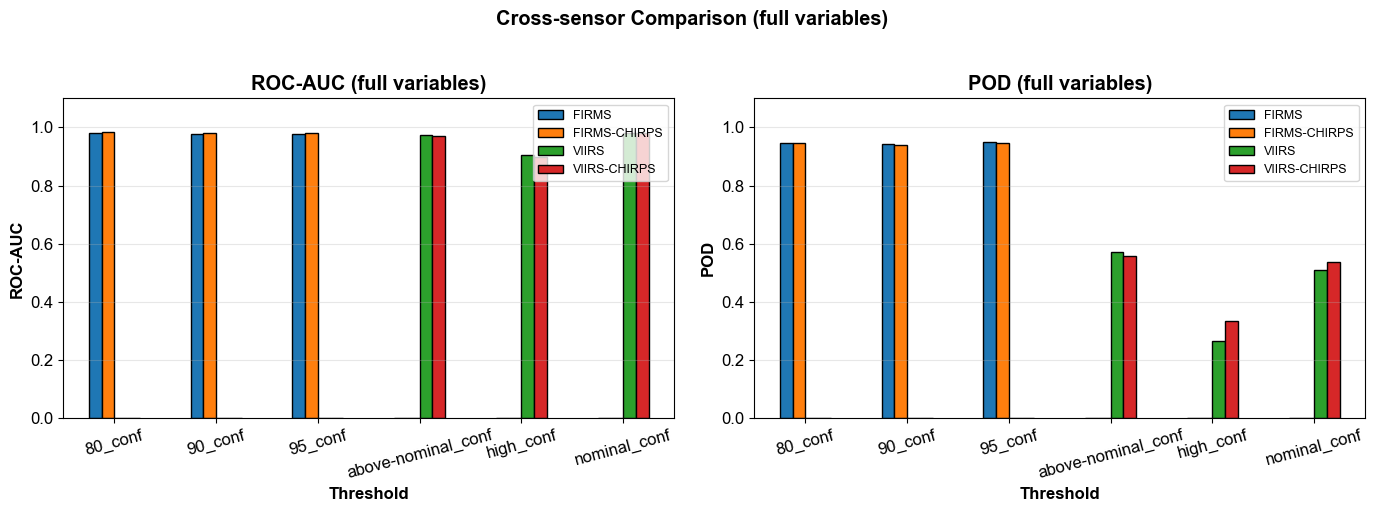

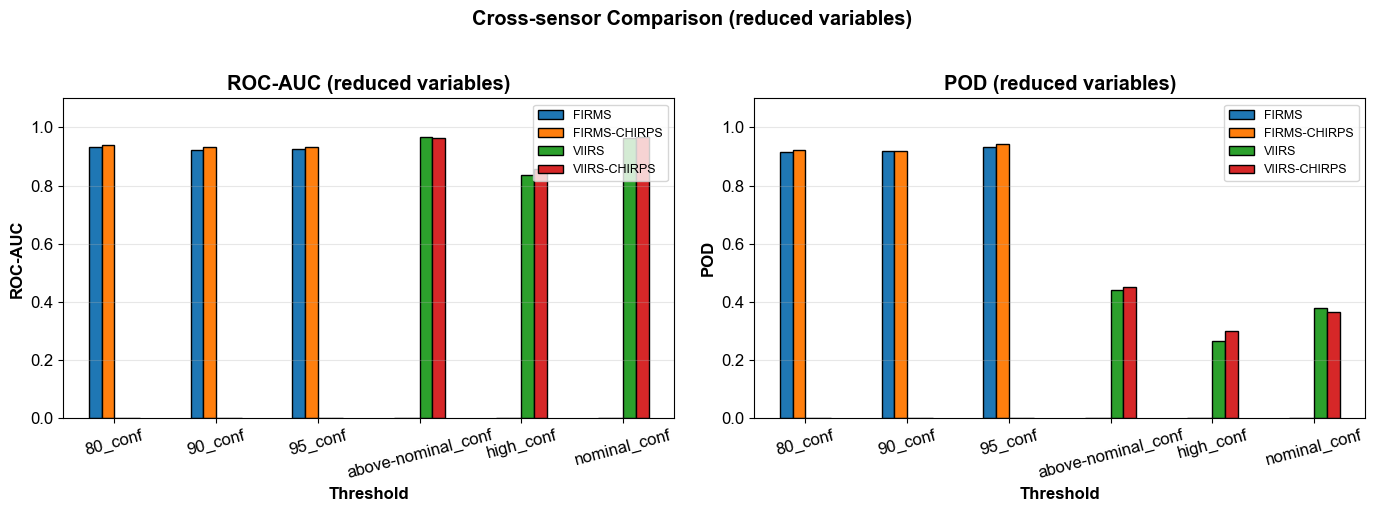

In [16]:
for var_filter, title_suffix in [('full', 'full variables'), ('reduced', 'reduced variables')]:
    subset = all_results[all_results['Variables'] == var_filter].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ['ROC-AUC', 'POD']):
        pivot = subset.pivot(index='Threshold', columns='Sensor', values=metric)
        pivot.plot(kind='bar', ax=ax, edgecolor='black')
        ax.set_title(f'{metric} ({title_suffix})', fontweight='bold')
        ax.set_xlabel('Threshold'); ax.set_ylabel(metric)
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=15)
        ax.legend(fontsize=9)
    plt.suptitle(f'Cross-sensor Comparison ({title_suffix})', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()